<a href="https://colab.research.google.com/github/KuwarAbhinavAman/EDA-TASK-5/blob/main/Titanic_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0       

<Figure size 1000x600 with 0 Axes>

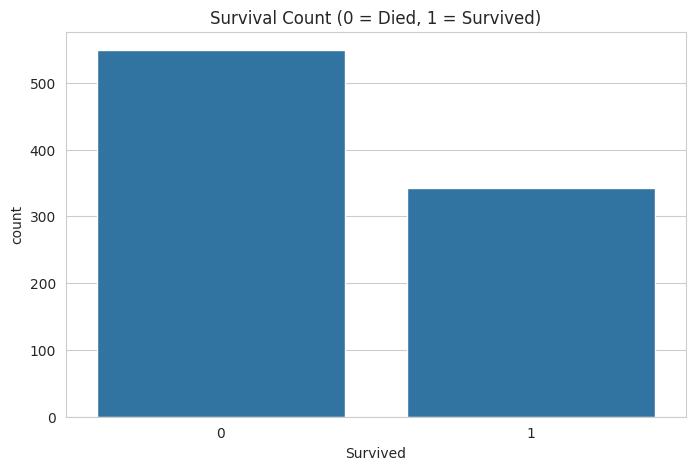

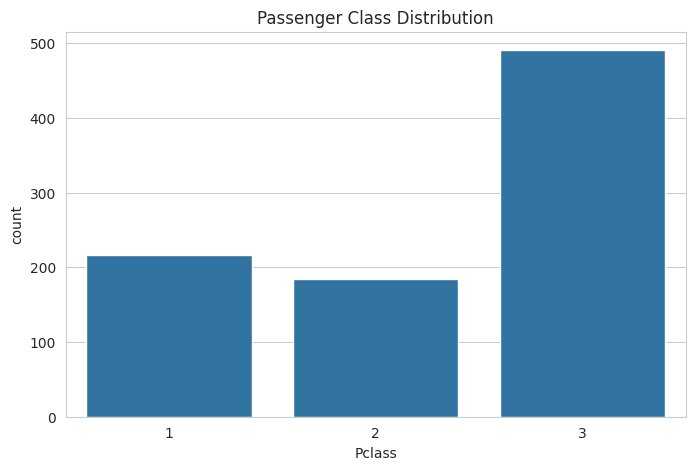

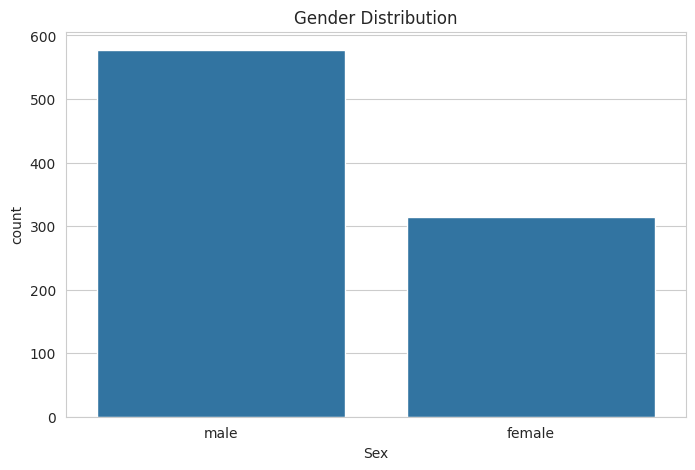

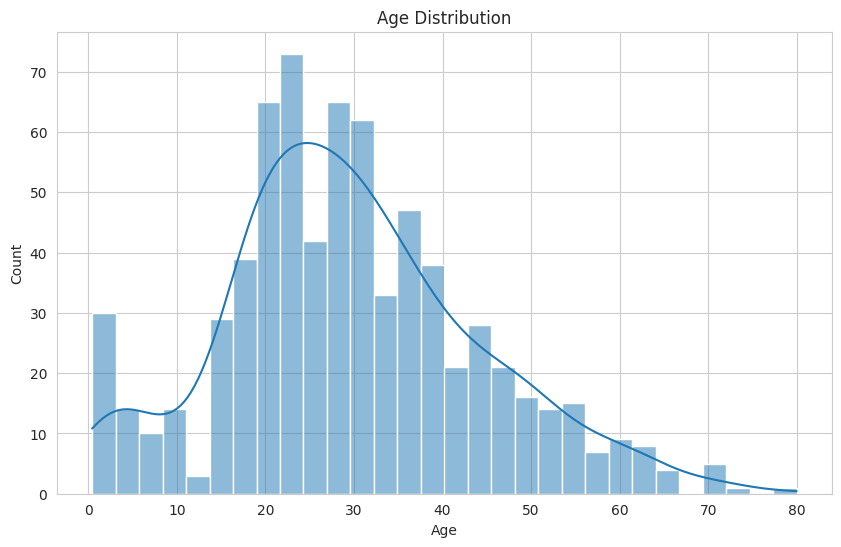

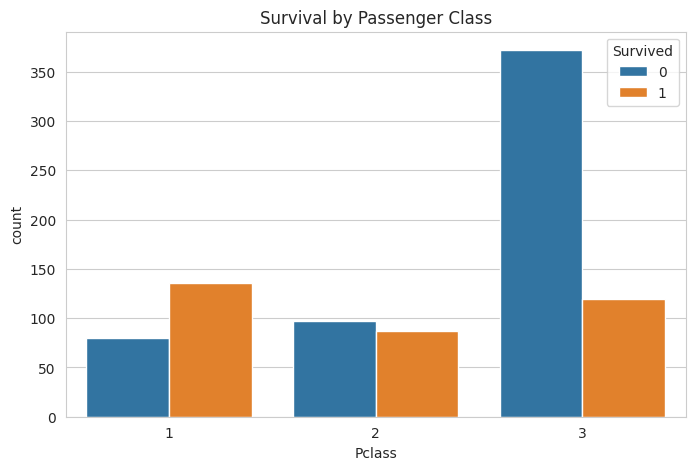

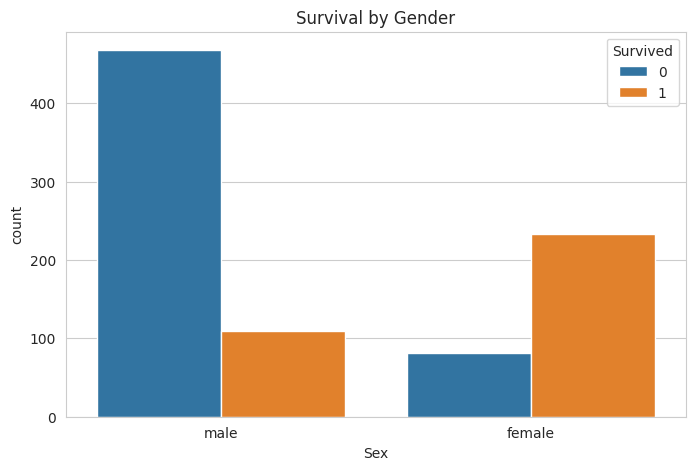

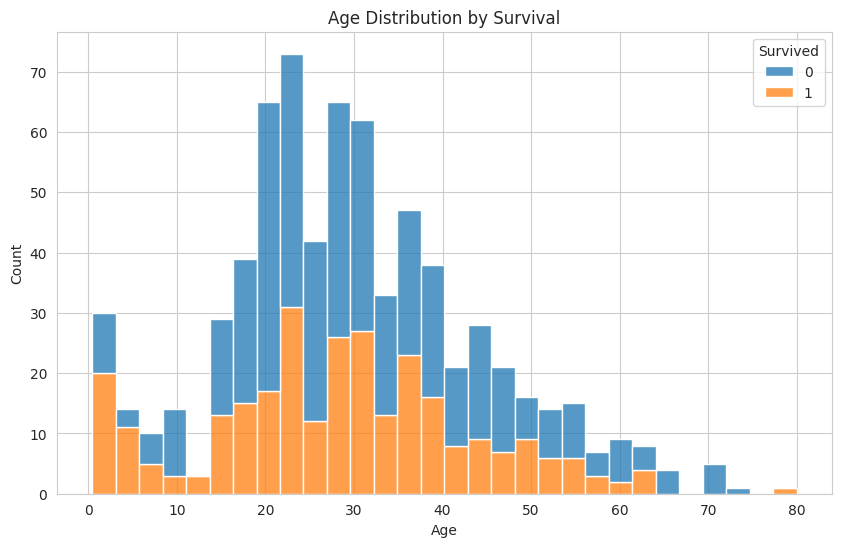

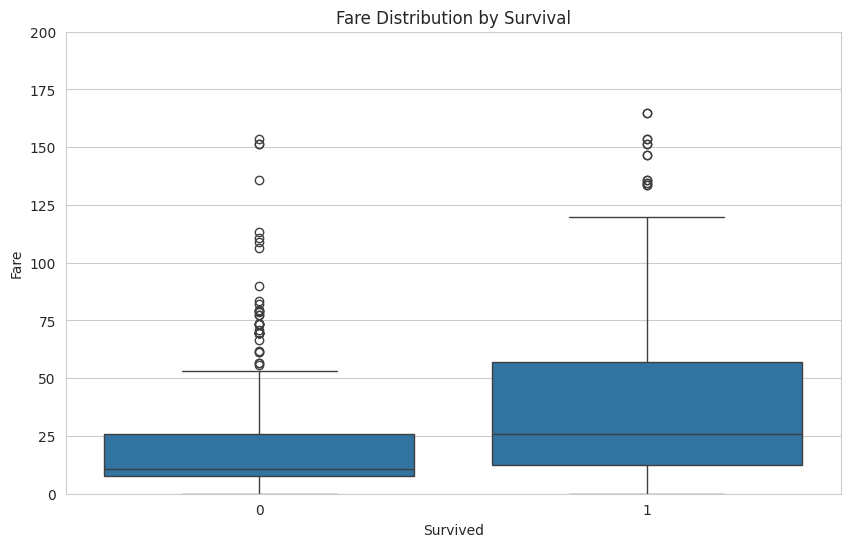

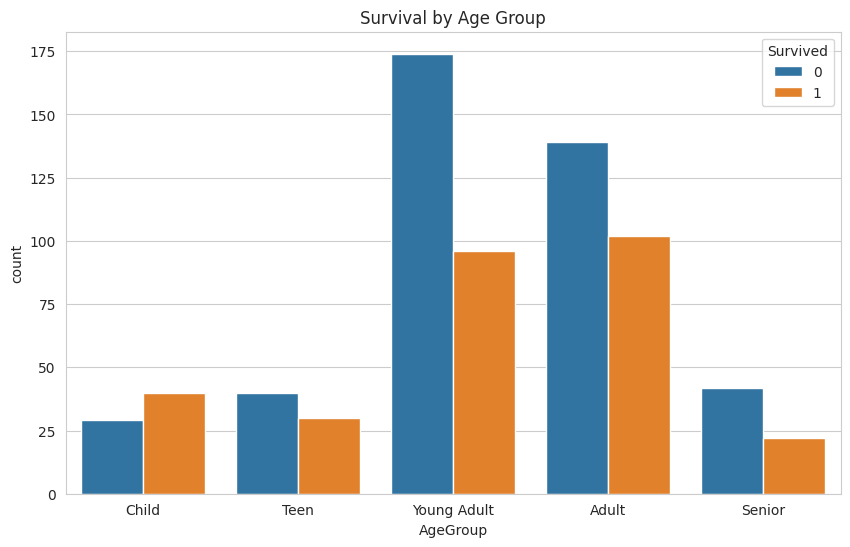

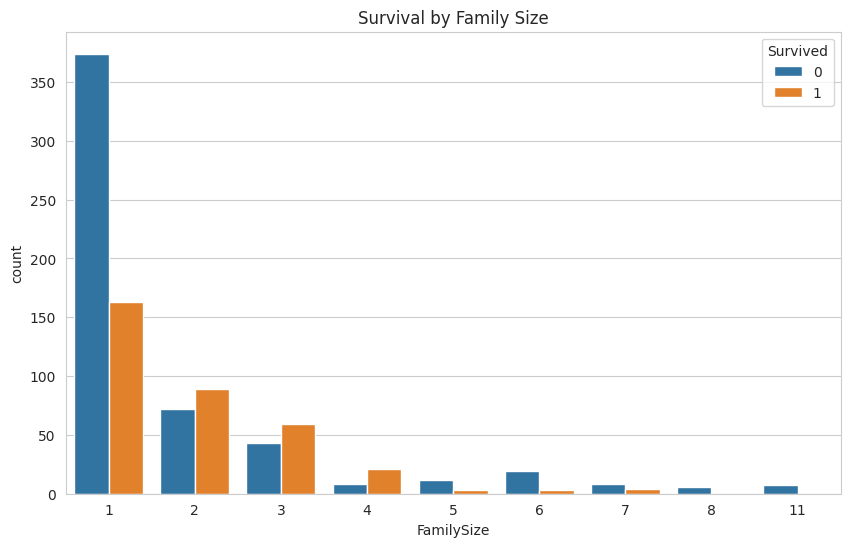

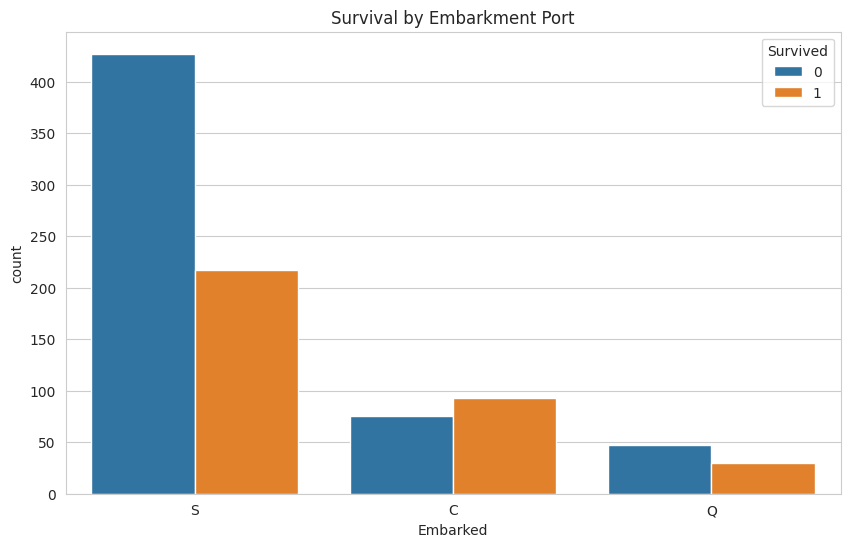

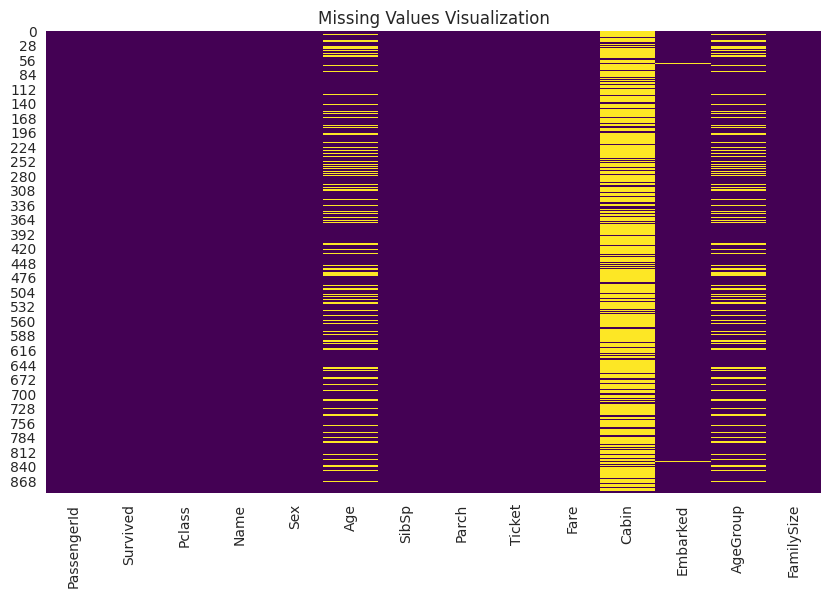

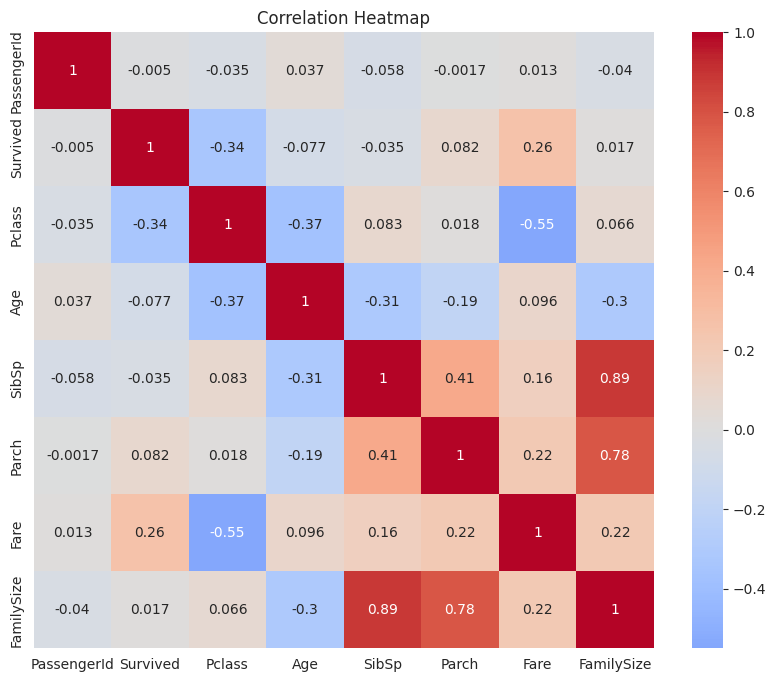

'\nFINAL SUMMARY OF FINDINGS:\n\n1. DEMOGRAPHICS:\n- 891 passengers in dataset (38% survived)\n- Majority male (65%), mostly aged 20-40\n- Most common class was 3rd (55% of passengers)\n\n2. SURVIVAL FACTORS:\n- Class: 1st class had 63% survival vs 24% in 3rd class\n- Gender: 74% female survival vs 19% male\n- Age: Children had highest survival rates (60%)\n- Fare: Survivors paid significantly higher fares\n\n3. FAMILY IMPACT:\n- Solo travelers had worst survival rates\n- Small families (2-4 members) had best chances\n- Large families struggled to survive together\n\n4. OTHER PATTERNS:\n- Cherbourg passengers survived more (55%)\n- Cabin information mostly missing (77%)\n- Strong correlation between class and survival\n\n5. ANOMALIES:\n- Some high-fare passengers in 3rd class\n- Few elderly survivors despite "women and children first"\n- Several young adult males survived against odds\n\nRECOMMENDATIONS FOR FURTHER ANALYSIS:\n1. Investigate interaction effects (e.g., class + gender)\n2

In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
titanic = pd.read_csv('train.csv')

# Initial data exploration
print("Dataset shape:", titanic.shape)
print("\nFirst 5 rows:")
print(titanic.head())
print("\nData types and missing values:")
print(titanic.info())
print("\nSummary statistics:")
print(titanic.describe(include='all'))

# Check for missing values
print("\nMissing values per column:")
print(titanic.isnull().sum())

# Set up visual style
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))

# ======================
# 1. Basic Distributions
# ======================

# 1.1 Survival distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', data=titanic)
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()
"""
Observation:
- Only about 38% of passengers survived (342 out of 891)
- Significant class imbalance with more deaths than survivors
"""

# 1.2 Passenger class distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', data=titanic)
plt.title('Passenger Class Distribution')
plt.show()
"""
Observation:
- Majority of passengers were in 3rd class (491 passengers)
- 1st class had 216 passengers, 2nd class had 184
"""

# 1.3 Gender distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', data=titanic)
plt.title('Gender Distribution')
plt.show()
"""
Observation:
- Significant male majority (577 males vs 314 females)
- About 65% of passengers were male
"""

# 1.4 Age distribution
plt.figure(figsize=(10,6))
sns.histplot(titanic['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')
plt.show()
"""
Observation:
- Right-skewed distribution with most passengers between 20-40 years
- Few children (under 12) and elderly (over 60)
- Mean age around 30 years
"""

# ===========================
# 2. Survival Analysis
# ===========================

# 2.1 Survival by passenger class
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived', data=titanic)
plt.title('Survival by Passenger Class')
plt.show()
"""
Observation:
- Strong class bias in survival rates
- 1st class had highest survival rate (~63%)
- 3rd class had lowest survival rate (~24%)
"""

# 2.2 Survival by gender
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', hue='Survived', data=titanic)
plt.title('Survival by Gender')
plt.show()
"""
Observation:
- Dramatic gender difference in survival
- ~74% of females survived vs only ~19% of males
- "Women and children first" policy evident
"""

# 2.3 Age distribution by survival
plt.figure(figsize=(10,6))
sns.histplot(data=titanic, x='Age', hue='Survived', multiple='stack', bins=30)
plt.title('Age Distribution by Survival')
plt.show()
"""
Observation:
- Children (under 12) had higher survival rates
- Peak deaths in 20-40 age range (most common age group)
- Elderly passengers (60+) had low survival rates
"""

# 2.4 Fare distribution by survival
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived', y='Fare', data=titanic)
plt.ylim(0, 200)  # Limit to see majority of data
plt.title('Fare Distribution by Survival')
plt.show()
"""
Observation:
- Survivors generally paid higher fares
- Median fare for survivors: ~£26 vs ~£8 for non-survivors
- Many outliers in fare amounts, especially among survivors
"""

# ======================
# 3. Advanced Analysis
# ======================

# 3.1 Age groups analysis
titanic['AgeGroup'] = pd.cut(titanic['Age'], bins=[0, 12, 18, 30, 50, 100],
                            labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
plt.figure(figsize=(10,6))
sns.countplot(x='AgeGroup', hue='Survived', data=titanic)
plt.title('Survival by Age Group')
plt.show()
"""
Observation:
- Children had highest survival rate (~60%)
- Survival rates decrease with age after young adulthood
- Teens and young adults had similar survival rates (~35-40%)
"""

# 3.2 Family size analysis
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
plt.figure(figsize=(10,6))
sns.countplot(x='FamilySize', hue='Survived', data=titanic)
plt.title('Survival by Family Size')
plt.show()
"""
Observation:
- Solo travelers had lowest survival rate (~30%)
- Families of 2-4 had best survival chances (~50-70%)
- Very large families (5+) had poor survival rates
"""

# 3.3 Embarkment port analysis
plt.figure(figsize=(10,6))
sns.countplot(x='Embarked', hue='Survived', data=titanic)
plt.title('Survival by Embarkment Port')
plt.show()
"""
Observation:
- Cherbourg (C) passengers had highest survival rate (~55%)
- Southampton (S) had lowest survival rate (~34%)
- Possible correlation with passenger class distribution by port
"""

# 3.4 Missing values visualization
plt.figure(figsize=(10,6))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Visualization')
plt.show()
"""
Observation:
- Age has about 20% missing values (needs imputation)
- Cabin has 77% missing (likely indicates most passengers didn't have cabins)
- Embarked has only 2 missing values
"""

# 3.5 Correlation heatmap
corr = titanic.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()
"""
Observation:
- Strongest positive correlation with survival: Fare (0.26)
- Strongest negative correlation: Pclass (-0.34)
- Age has weak correlation with survival (-0.08)
- Family size (SibSp + Parch) shows small positive correlation (0.02)
"""

# ======================
# Summary of Findings
# ======================

"""
FINAL SUMMARY OF FINDINGS:

1. DEMOGRAPHICS:
- 891 passengers in dataset (38% survived)
- Majority male (65%), mostly aged 20-40
- Most common class was 3rd (55% of passengers)

2. SURVIVAL FACTORS:
- Class: 1st class had 63% survival vs 24% in 3rd class
- Gender: 74% female survival vs 19% male
- Age: Children had highest survival rates (60%)
- Fare: Survivors paid significantly higher fares

3. FAMILY IMPACT:
- Solo travelers had worst survival rates
- Small families (2-4 members) had best chances
- Large families struggled to survive together

4. OTHER PATTERNS:
- Cherbourg passengers survived more (55%)
- Cabin information mostly missing (77%)
- Strong correlation between class and survival

5. ANOMALIES:
- Some high-fare passengers in 3rd class
- Few elderly survivors despite "women and children first"
- Several young adult males survived against odds

RECOMMENDATIONS FOR FURTHER ANALYSIS:
1. Investigate interaction effects (e.g., class + gender)
2. Explore title extraction from names (Mr/Mrs/Miss)
3. Examine cabin letter patterns for survivors
4. Model building with these key features
"""